# K-Nearest Neighbors: Deep Dive
## Loan Default Prediction (HMEQ Dataset)

*Part of the [ML Model Comparison](../loan_default_tradeoff_matrix.html) series on bitterscientist.com*

This notebook covers:
1. The math behind KNN (distance metrics, voting, weighting)
2. Worked examples using actual HMEQ data
3. Model training with hyperparameter tuning
4. Diagnostic visualizations (exported as interactive plotly HTML)
5. Results interpretation

---
## 1. Setup

In [1]:
import sys
sys.path.insert(0, ".")
from shared_utils import *

from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

MODEL_NAME = "K-Nearest Neighbors"
MODEL_SLUG = "knn"

(X_train, X_test, y_train, y_test, df, df_proc,
 prep_linear, prep_tree, cv,
 numeric_features, categorical_features, pos_weight) = load_and_prep()

Dataset loaded: 5960 rows, 13 columns
Default rate: 19.95%
Train: 4470 | Test: 1490
Numeric features: 15 | Categorical: 2
Positive class weight: 4.01


---
## 2. The Math Behind KNN

### 2.1 The Core Idea

KNN is a **non-parametric, instance-based** algorithm. It makes no assumptions about the underlying data distribution and does not learn explicit parameters during training. Instead, it memorizes the entire training set and classifies new points by looking at their nearest neighbors.

For a new borrower $\mathbf{x}_q$:
1. Compute the distance from $\mathbf{x}_q$ to every training sample
2. Find the $K$ closest training samples (the "neighbors")
3. Classify $\mathbf{x}_q$ by majority vote among the $K$ neighbors

### 2.2 Distance Metrics

The most common distance metric is **Euclidean distance**:

$$d(\mathbf{x}_q, \mathbf{x}_i) = \sqrt{\sum_{j=1}^{p} (x_{q,j} - x_{i,j})^2}$$

Other options include:

**Manhattan distance** (L1):
$$d(\mathbf{x}_q, \mathbf{x}_i) = \sum_{j=1}^{p} |x_{q,j} - x_{i,j}|$$

**Minkowski distance** (generalized, with parameter $p$):
$$d(\mathbf{x}_q, \mathbf{x}_i) = \left(\sum_{j=1}^{p} |x_{q,j} - x_{i,j}|^m \right)^{1/m}$$

where $m=2$ gives Euclidean and $m=1$ gives Manhattan.

### 2.3 Classification by Majority Vote

For **uniform weighting** (default), each of the $K$ neighbors gets one vote:

$$\hat{y} = \arg\max_{c} \sum_{i \in N_K(\mathbf{x}_q)} \mathbb{1}(y_i = c)$$

where $N_K(\mathbf{x}_q)$ is the set of $K$ nearest neighbors and $\mathbb{1}(\cdot)$ is the indicator function.

For **distance weighting**, closer neighbors get more influence:

$$\hat{y} = \arg\max_{c} \sum_{i \in N_K(\mathbf{x}_q)} \frac{1}{d(\mathbf{x}_q, \mathbf{x}_i)} \cdot \mathbb{1}(y_i = c)$$

### 2.4 Probability Estimation

KNN can also output class probabilities:

$$\hat{P}(Y=1 \mid \mathbf{x}_q) = \frac{1}{K} \sum_{i \in N_K(\mathbf{x}_q)} \mathbb{1}(y_i = 1)$$

This is simply the fraction of neighbors that are defaults. With $K=5$, the only possible probability values are $\{0, 0.2, 0.4, 0.6, 0.8, 1.0\}$.

### 2.5 The Curse of Dimensionality

In high-dimensional spaces, distances become less meaningful. As the number of features $p$ grows, the volume of the feature space grows exponentially, and all points become roughly equidistant. This is why **feature scaling is critical** for KNN and why dimensionality reduction can help.

### 2.6 Why Feature Scaling Matters

Without scaling, features with large magnitudes dominate the distance calculation:

$$d = \sqrt{(\text{LOAN}_q - \text{LOAN}_i)^2 + (\text{YOJ}_q - \text{YOJ}_i)^2}$$

If LOAN ranges from 1,100 to 89,900 and YOJ ranges from 0 to 41, LOAN will completely dominate the distance. StandardScaler ensures each feature contributes equally.

### 2.7 Choosing K

- **Small K** (e.g., 1 or 3): Low bias, high variance. The model is very sensitive to local noise.
- **Large K** (e.g., 50+): High bias, low variance. The model smooths over local patterns.
- **K = N**: Every query point is classified as the majority class (the most biased model).
- **Odd K**: Avoids ties in binary classification.

The optimal $K$ is found by cross-validation.

---
## 3. Visualizing Distance Metrics

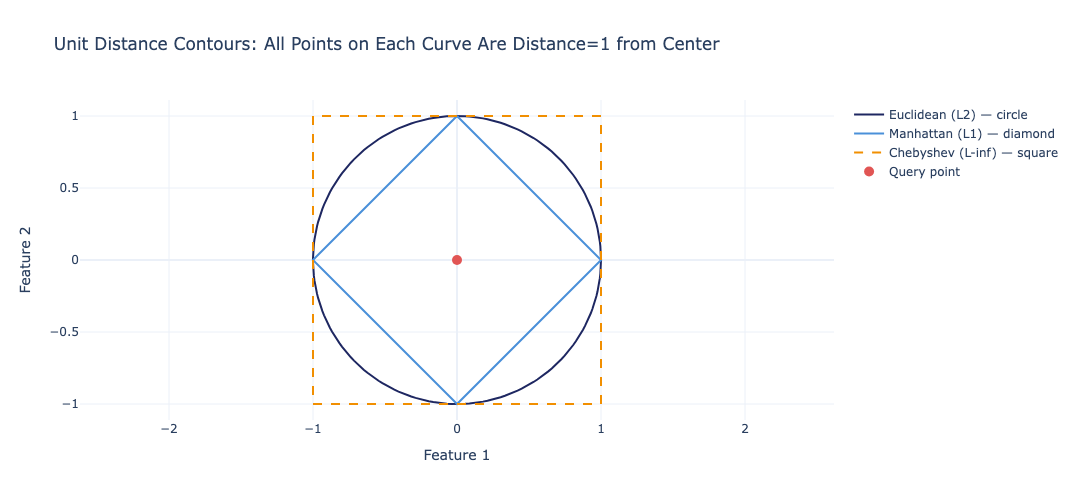

  Saved: outputs/knn/distance_metrics.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/knn/distance_metrics.html')

In [2]:
# Compare distance metrics in 2D
theta = np.linspace(0, 2 * np.pi, 200)

fig = go.Figure()

# Euclidean: circle of radius 1
fig.add_trace(go.Scatter(x=np.cos(theta), y=np.sin(theta),
    mode="lines", name="Euclidean (L2) — circle",
    line=dict(color=COLORS["navy"], width=2)))

# Manhattan: diamond of radius 1
t = np.linspace(0, 1, 50)
x_man = np.concatenate([t, 1 - t, -t, t - 1])
y_man = np.concatenate([1 - t, -t, t - 1, t])
fig.add_trace(go.Scatter(x=x_man, y=y_man,
    mode="lines", name="Manhattan (L1) — diamond",
    line=dict(color=COLORS["accent"], width=2)))

# Chebyshev: square of radius 1
fig.add_trace(go.Scatter(
    x=[-1, 1, 1, -1, -1], y=[-1, -1, 1, 1, -1],
    mode="lines", name="Chebyshev (L-inf) — square",
    line=dict(color=COLORS["orange"], width=2, dash="dash")))

fig.add_trace(go.Scatter(x=[0], y=[0], mode="markers",
    marker=dict(size=10, color=COLORS["red"]), name="Query point"))

fig.update_layout(
    title="Unit Distance Contours: All Points on Each Curve Are Distance=1 from Center",
    xaxis=dict(scaleanchor="y", scaleratio=1, title="Feature 1"),
    yaxis=dict(title="Feature 2"),
    height=500, width=550,
)
fig.show()
save_chart(fig, MODEL_SLUG, "distance_metrics")

---
## 4. Worked Example with HMEQ Data

Let's manually walk through the KNN prediction for a real borrower.

In [3]:
# Transform data first
X_train_t = prep_linear.fit_transform(X_train)
X_test_t = prep_linear.transform(X_test)

# Get feature names
cat_encoder = prep_linear.named_transformers_["cat"]
cat_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_names

# Pick a test sample
examples = get_example_rows(df, n=3)

# Train KNN with K=5 for demonstration
knn_demo = KNeighborsClassifier(n_neighbors=5, weights="uniform", metric="euclidean")
knn_demo.fit(X_train_t, y_train)

print("=" * 70)
print("WORKED EXAMPLE: KNN Prediction (K=5, Euclidean Distance)")
print("=" * 70)

# Use first test sample
test_idx = 0
x_query = X_test_t[test_idx:test_idx+1]
actual = y_test.iloc[test_idx]

# Find 5 nearest neighbors
distances, indices = knn_demo.kneighbors(x_query, n_neighbors=5)

print(f"\nQuery borrower (Actual: {'DEFAULT' if actual == 1 else 'GOOD'})")
print(f"\nStep 1: Find the 5 nearest neighbors (by Euclidean distance)")
print(f"{'Rank':<6} {'Distance':<12} {'Class':<10} {'Label'}")
print("-" * 40)
for rank, (dist, idx) in enumerate(zip(distances[0], indices[0]), 1):
    label = "DEFAULT" if y_train.iloc[idx] == 1 else "GOOD"
    print(f"{rank:<6} {dist:<12.4f} {y_train.iloc[idx]:<10} {label}")

n_default = sum(y_train.iloc[idx] == 1 for idx in indices[0])
n_good = 5 - n_default
prob_default = n_default / 5

print(f"\nStep 2: Count votes")
print(f"  Good loans: {n_good}/5")
print(f"  Defaults:   {n_default}/5")

print(f"\nStep 3: Compute probability and classify")
print(f"  P(default) = {n_default}/5 = {prob_default:.2f}")
prediction = "DEFAULT" if prob_default >= 0.5 else "GOOD"
actual_str = "DEFAULT" if actual == 1 else "GOOD"
match = "CORRECT" if prediction == actual_str else "INCORRECT"
print(f"  Prediction: {prediction} (threshold = 0.5)")
print(f"  Actual: {actual_str}  {match}")

WORKED EXAMPLE: KNN Prediction (K=5, Euclidean Distance)

Query borrower (Actual: DEFAULT)

Step 1: Find the 5 nearest neighbors (by Euclidean distance)
Rank   Distance     Class      Label
----------------------------------------
1      2.3442       0          GOOD
2      2.4084       1          DEFAULT
3      2.4569       1          DEFAULT
4      2.4709       1          DEFAULT
5      2.6377       1          DEFAULT

Step 2: Count votes
  Good loans: 1/5
  Defaults:   4/5

Step 3: Compute probability and classify
  P(default) = 4/5 = 0.80
  Prediction: DEFAULT (threshold = 0.5)
  Actual: DEFAULT  CORRECT


---
## 5. Model Training with Hyperparameter Tuning

In [4]:
param_grid = {
    "clf__n_neighbors": [3, 5, 7, 11, 15, 21, 31],
    "clf__weights": ["uniform", "distance"],
    "clf__metric": ["euclidean", "manhattan"],
}

knn_pipe = Pipeline([
    ("prep", prep_linear),
    ("clf", KNeighborsClassifier()),
])

grid = GridSearchCV(
    knn_pipe, param_grid, cv=cv,
    scoring="recall", n_jobs=-1, refit=True,
)
grid.fit(X_train, y_train)

best_knn = grid.best_estimator_
print(f"Best parameters: {grid.best_params_}")
print(f"Best CV recall: {grid.best_score_:.4f}")

Best parameters: {'clf__metric': 'euclidean', 'clf__n_neighbors': 3, 'clf__weights': 'distance'}
Best CV recall: 0.6211


---
## 6. Model Evaluation

In [5]:
cv_scores = cross_val_score(best_knn, X_train, y_train, cv=cv, scoring="recall")
cv_mean = cv_scores.mean()
print(f"CV Recall: {cv_mean:.4f} (+/- {cv_scores.std():.4f})")

metrics, y_pred, y_score = evaluate_model(MODEL_NAME, best_knn, X_test, y_test, cv_mean)

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Good Loan", "Default"]))

CV Recall: 0.6211 (+/- 0.0120)

  K-Nearest Neighbors
  Recall: 0.5993  |  Precision: 0.8476  |  F1: 0.7022
  AUC: 0.8731  |  PR-AUC: 0.7424
  Confusion: TP=178 FP=32 FN=119 TN=1161

Classification Report:
              precision    recall  f1-score   support

   Good Loan       0.91      0.97      0.94      1193
     Default       0.85      0.60      0.70       297

    accuracy                           0.90      1490
   macro avg       0.88      0.79      0.82      1490
weighted avg       0.90      0.90      0.89      1490



---
## 7. K vs Performance

How does the choice of K affect the bias-variance tradeoff?

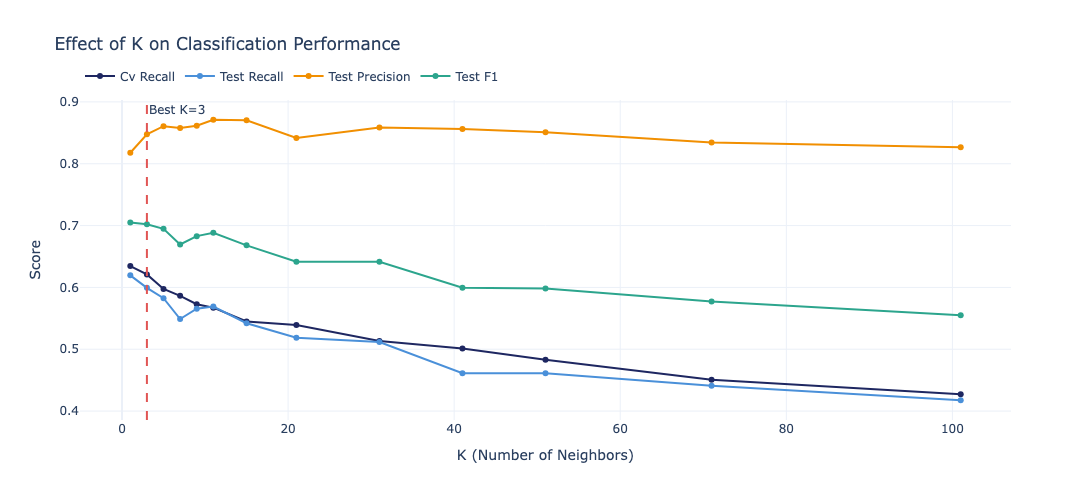

  Saved: outputs/knn/k_vs_metrics.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/knn/k_vs_metrics.html')

In [6]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 41, 51, 71, 101]
k_results = []

best_weight = best_knn.named_steps["clf"].weights
best_metric = best_knn.named_steps["clf"].metric

for k in k_values:
    knn_temp = Pipeline([
        ("prep", prep_linear),
        ("clf", KNeighborsClassifier(n_neighbors=k, weights=best_weight, metric=best_metric)),
    ])
    cv_sc = cross_val_score(knn_temp, X_train, y_train, cv=cv, scoring="recall").mean()
    knn_temp.fit(X_train, y_train)
    y_pred_t = knn_temp.predict(X_test)
    y_prob_t = knn_temp.predict_proba(X_test)[:, 1]

    k_results.append({
        "k": k,
        "cv_recall": cv_sc,
        "test_recall": recall_score(y_test, y_pred_t),
        "test_precision": precision_score(y_test, y_pred_t, zero_division=0),
        "test_f1": f1_score(y_test, y_pred_t),
        "test_auc": roc_auc_score(y_test, y_prob_t),
    })

df_k = pd.DataFrame(k_results)

fig_k = go.Figure()
for metric_name, color in [("cv_recall", COLORS["navy"]), ("test_recall", COLORS["accent"]),
                            ("test_precision", COLORS["orange"]), ("test_f1", COLORS["green"])]:
    fig_k.add_trace(go.Scatter(
        x=df_k["k"], y=df_k[metric_name],
        name=metric_name.replace("_", " ").title(),
        line=dict(color=color, width=2), mode="lines+markers",
    ))

best_k = best_knn.named_steps["clf"].n_neighbors
fig_k.add_vline(x=best_k, line_dash="dash", line_color=COLORS["red"],
                annotation_text=f"Best K={best_k}")

fig_k.update_layout(
    title="Effect of K on Classification Performance",
    xaxis_title="K (Number of Neighbors)",
    yaxis_title="Score",
    height=500, width=700,
    legend=dict(orientation="h", y=1.12),
)
fig_k.show()
save_chart(fig_k, MODEL_SLUG, "k_vs_metrics")

---
## 8. Distance Distribution

How are the distances to neighbors distributed? Are good loans and defaults at different distances?

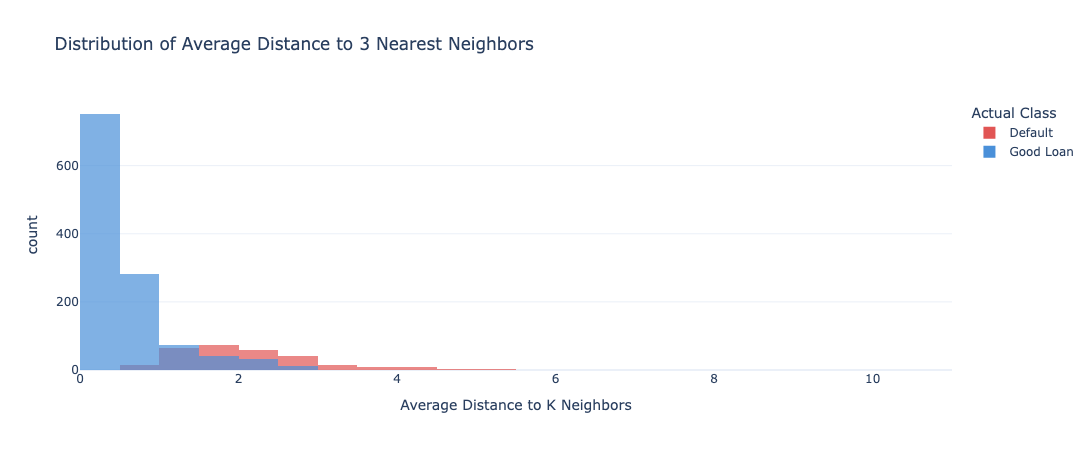

  Saved: outputs/knn/distance_distribution.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/knn/distance_distribution.html')

In [7]:
# Compute average distance to K nearest neighbors for each test sample
knn_fitted = best_knn.named_steps["clf"]
X_test_tr = prep_linear.transform(X_test)
distances_all, _ = knn_fitted.kneighbors(X_test_tr)
avg_distances = distances_all.mean(axis=1)

dist_df = pd.DataFrame({
    "avg_distance": avg_distances,
    "actual": y_test.map({0: "Good Loan", 1: "Default"}).values,
    "predicted": ["Default" if p == 1 else "Good Loan" for p in y_pred],
})

fig_dist = px.histogram(
    dist_df, x="avg_distance", color="actual",
    nbins=50, barmode="overlay", opacity=0.7,
    title=f"Distribution of Average Distance to {best_k} Nearest Neighbors",
    labels={"avg_distance": "Average Distance to K Neighbors", "actual": "Actual Class"},
    color_discrete_map={"Good Loan": COLORS["accent"], "Default": COLORS["red"]},
    height=450, width=650,
)
fig_dist.show()
save_chart(fig_dist, MODEL_SLUG, "distance_distribution")

---
## 9. Decision Boundary (2D PCA Projection)

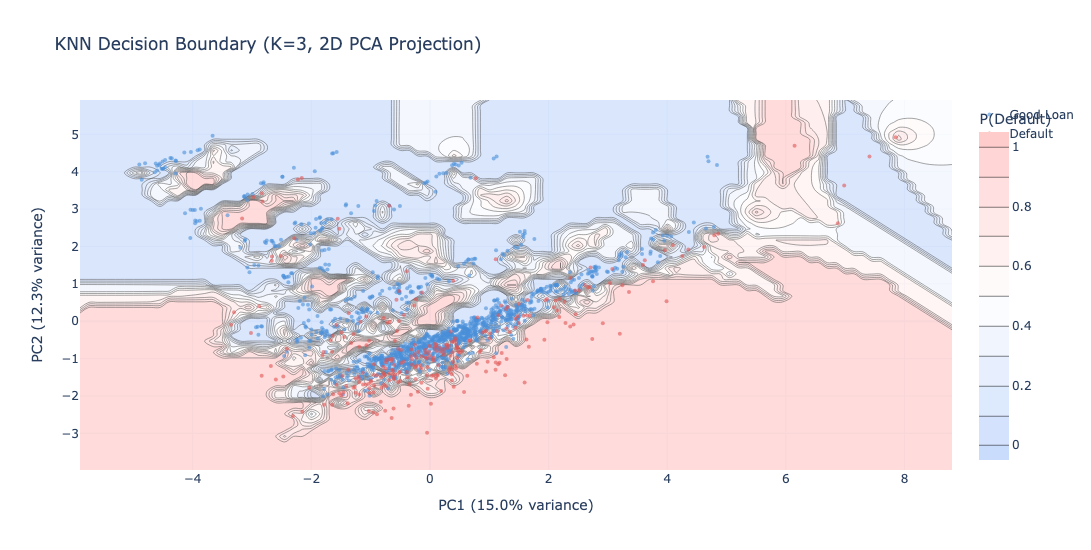

  Saved: outputs/knn/decision_boundary_2d.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/knn/decision_boundary_2d.html')

In [8]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_t)
X_test_2d = pca.transform(X_test_t)

knn_2d = KNeighborsClassifier(
    n_neighbors=best_k, weights=best_weight, metric=best_metric
)
knn_2d.fit(X_train_2d, y_train)

h = 0.15
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = knn_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig_db = go.Figure()
fig_db.add_trace(go.Contour(
    x=np.arange(x_min, x_max, h), y=np.arange(y_min, y_max, h), z=Z,
    colorscale=[[0, COLORS["ice"]], [0.5, COLORS["white"]], [1, "#ffcccc"]],
    contours=dict(start=0, end=1, size=0.1),
    showscale=True, colorbar=dict(title="P(Default)"), opacity=0.7,
))
for label, color, name in [(0, COLORS["accent"], "Good Loan"), (1, COLORS["red"], "Default")]:
    mask = y_test == label
    fig_db.add_trace(go.Scatter(
        x=X_test_2d[mask, 0], y=X_test_2d[mask, 1],
        mode="markers", name=name,
        marker=dict(color=color, size=4, opacity=0.6),
    ))

fig_db.update_layout(
    title=f"KNN Decision Boundary (K={best_k}, 2D PCA Projection)",
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)",
    height=550, width=700,
)
fig_db.show()
save_chart(fig_db, MODEL_SLUG, "decision_boundary_2d")

---
## 10. Diagnostic Charts


Saving universal charts for K-Nearest Neighbors:
  Saved: outputs/knn/roc_curve.html
  Saved: outputs/knn/precision_recall_curve.html
  Saved: outputs/knn/confusion_matrix.html
  Saved: outputs/knn/threshold_sweep.html


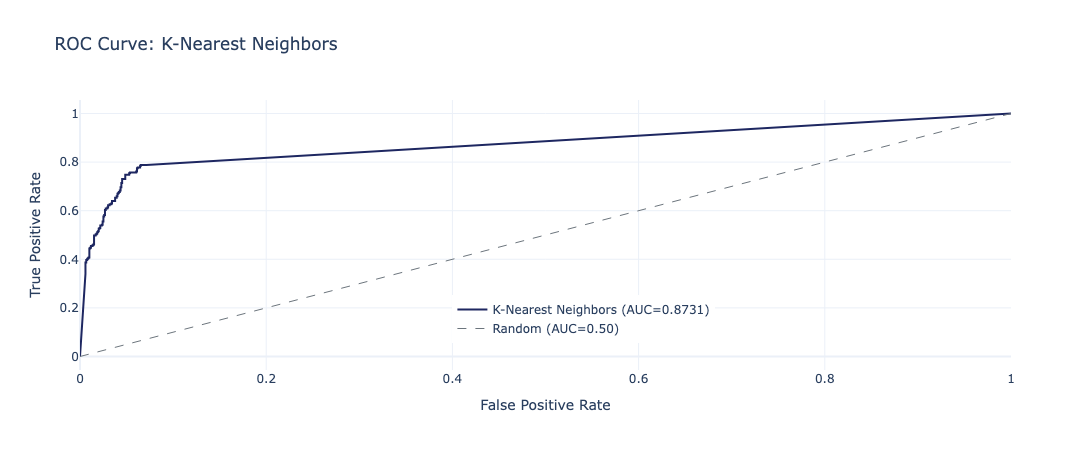

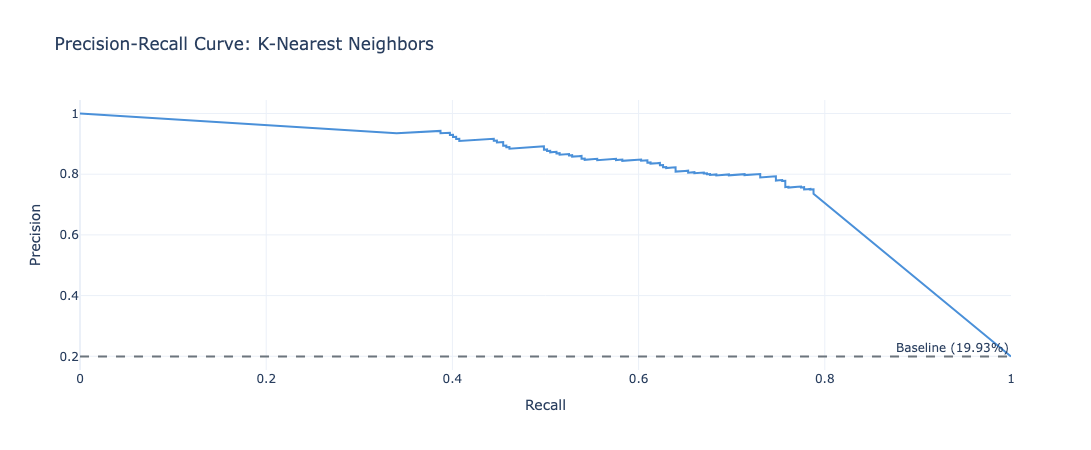

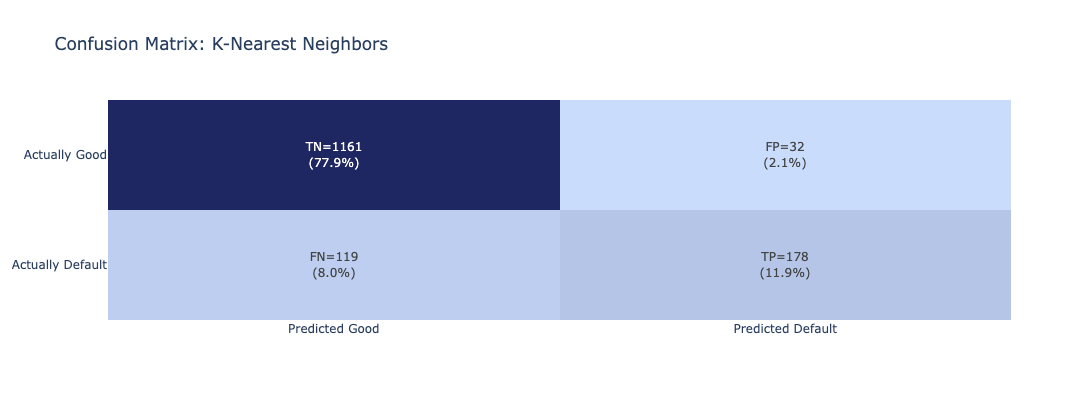

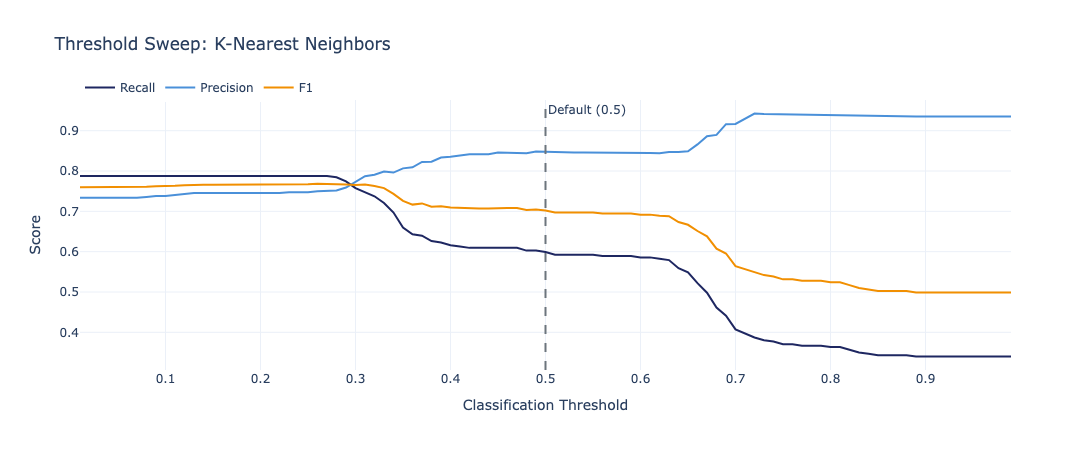

In [9]:
charts = save_all_universal_charts(y_test, y_pred, y_score, MODEL_NAME, MODEL_SLUG)
for name, fig in charts.items():
    fig.show()

---
## 11. Summary

### Where KNN Sits on the Tradeoff Spectrum

KNN's position on the spectrum depends heavily on K and the class balance in local neighborhoods. With small K, it tends toward aggressive predictions (high recall, lower precision) because minority class neighbors can dominate small neighborhoods. With large K, it drifts toward the conservative side as the majority class dominates.

### Strengths for This Problem
- No training phase (lazy learning): the model adapts immediately to new data
- Naturally nonlinear: can capture complex decision boundaries
- Intuitive: "show me borrowers like this one and tell me what happened to them"
- Works well when the decision boundary is locally smooth

### Limitations for This Problem
- Slow at prediction time (must compute distance to all training points)
- Sensitive to feature scaling (StandardScaler is mandatory)
- Suffers from the curse of dimensionality with many features
- Cannot provide feature importance or interpretable rules
- Memory intensive (stores entire training set)
- Sensitive to class imbalance in local neighborhoods

### Key Takeaway
KNN is the **instance-based baseline**: it predicts based on "what happened to similar borrowers." It works best when similar inputs should produce similar outputs (the smoothness assumption). For credit scoring, this means borrowers with similar financial profiles should have similar default outcomes. The lack of a parametric model makes it flexible but also means it offers no global summary of what drives default risk.

---
*Notebook by Trinidad Cisneros — MIT Applied Data Science Program, April 2026*